# 📊 Stock Return Model — Machine Learning Quant Project

This project is designed to develop a strong, practical understanding of the end-to-end machine learning pipeline applied to financial time series data, with a primary focus on intuition, robustness, and realistic evaluation rather than purely maximizing predictive accuracy.

---

## 🎯 Objective

The goal of this project is to explore and implement a complete quantitative modeling workflow on stock data, while critically evaluating each stage under realistic financial constraints.

The project covers:

- Feature engineering (momentum, volatility, volume change, lagged returns, rolling statistics, interaction terms, and nonlinear features)
- Data preprocessing (handling missing values, outlier removal using quantile filtering)
- Feature scaling (standardization using z-score normalization)
- Time-based train/test split (no data leakage, realistic out-of-sample evaluation)
- Model training using:
  - Linear regression (gradient descent)
  - Logistic regression (classification of return direction)
- Model evaluation using:
  - R² (regression)
  - Accuracy, confusion matrix, classification report (classification)
- Strategy construction using probability-based signals
- Backtesting using actual returns (out-of-sample)
- Regularization (L2) to control model complexity
- Visualization and diagnostics (cost curves, weight evolution, prediction plots)

---

## 🧠 Feature Engineering Approach

To enhance model expressiveness beyond basic features, several transformations were introduced:

- **Lag features**: past returns (`Return_lag1`, `Return_lag5`)
- **Rolling statistics**:
  - Momentum (rolling mean of returns)
  - Volatility (rolling standard deviation)
- **Interaction terms**:
  - Momentum × Volatility
  - Momentum × Volume Change
- **Nonlinear transformations**:
  - Squared features (e.g., `Momentum²`, `Volatility²`)

These features are designed to capture:
- temporal dependencies
- nonlinear relationships
- interaction effects between market variables

---

## 📈 Modeling Framework

### 1. Linear Regression (Next Return Prediction)

- Objective: predict the magnitude of next-period returns
- Optimization: gradient descent minimizing mean squared error
- Evaluation:
  - R² score
  - Actual vs Predicted plots
  - Weight evolution and convergence diagnostics

---

### 2. Logistic Regression (Direction Prediction)

- Objective: classify whether next return is positive or negative
- Output: probability of upward movement
- Decision rule:
  - Long if probability > 0.55
  - Short if probability < 0.45
  - No position otherwise

- Evaluation:
  - Accuracy
  - Confusion matrix
  - Classification report
  - Probability distribution analysis

---

### 3. Regularization (L2)

- Applied to logistic regression to control model complexity
- Helps prevent overfitting, especially with engineered features
- Observed effect:
  - Reduced weight magnitude (stabilization)
  - Slight trade-off between bias and variance

---

## 📊 Strategy Backtesting

A simple trading strategy is constructed from model outputs:

- Signals derived from predicted probabilities
- Returns computed using **actual next-period returns (not labels)**
- Portfolio performance evaluated using:
  - Cumulative return (compounded)
  - Average strategy return
  - Volatility
  - Sharpe-like ratio
  - Number of trades

---

## 📈 Results & Model Comparison

### Regression Models

| Model        | Features Used                        |      R²    |
|--------------|--------------------------------------|------------|
| Baseline     | Momentum, Volatility, Volume Change  | **-0.0009**|
| Engineered   | Full feature set                     | **0.0221** |

---

### 🔍 Key Observations

- The baseline model shows **near-zero explanatory power**, indicating that simple features are insufficient.
- Predictions from the baseline model are nearly constant → strong underfitting.
- Feature engineering improves R² by nearly **~24.5x×**, introducing meaningful structure.
- Despite improvement, R² remains low, reflecting the **noisy nature of financial returns**.

---

## 📊 Visualization Insights

- **Actual vs Predicted plots**:
  - Baseline → predictions clustered near zero
  - Engineered → greater dispersion and responsiveness
- **Perfect-fit reference line (y = x)** shows predictions remain far from ideal
- **Trend lines** confirm weak linear relationships
- **Cost vs Iteration plots** validate convergence behavior
- **Weight evolution plots** reveal stabilization of parameters

---

## ⚠️ Key Learnings

This project highlights several fundamental realities of quantitative finance:

- Financial markets exhibit **low signal-to-noise ratio**
- Predictive improvements are typically **incremental, not dramatic**
- Proper preprocessing (scaling, outlier handling) is critical
- Feature engineering is essential but not sufficient for strong predictability
- Classification (direction prediction) can sometimes be more practical than regression
- Out-of-sample evaluation is crucial to avoid misleading conclusions
- Backtesting must use **actual returns**, not classification labels

---

## 🧩 Summary

This project demonstrates a full pipeline from raw financial data to model evaluation and strategy backtesting, with a strong emphasis on understanding *why* models behave the way they do.

Rather than focusing solely on predictive performance, this work builds intuition around:

- feature design
- model limitations
- optimization behavior
- realistic evaluation through backtesting
- the gap between theoretical machine learning and real-world financial data

It serves as a solid foundation for more advanced quantitative research, including:

- factor modeling
- regime detection
- portfolio optimization
- and machine learning-based trading strategies

In [105]:
# Packages used
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.metrics import r2_score, accuracy_score, confusion_matrix, classification_report



In [106]:
# ==========================================
# Setup: Create output folder for saved files
# ==========================================
# This folder will store:
# 1. cleaned datasets
# 2. plots
# 3. summary tables
# ==========================================

import os
from datetime import datetime

# Ensure output directory exists
os.makedirs(output_dir, exist_ok=True)

# Timestamp for versioning
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
print(f"Output folder ready: {output_dir}")

Output folder ready: output


### Functions:

In [107]:
# ==========================================
# Linear Regression - Gradient Descent
# ==========================================
# This function trains a linear regression model
# using batch gradient descent.
# Objective: Minimize Mean Squared Error (MSE)
# ==========================================

def run_gradient_descent(x_train, y_train, w, b, iteration, alpha):
    # Ensure inputs are numpy arrays (for vectorized operations)
    x_train = np.array(x_train, dtype=float)
    y_train = np.array(y_train, dtype=float)
    w = np.array(w, dtype=float)
    
    # m = number of samples, n = number of features
    m, n = x_train.shape
    
    # Store training history for analysis/debugging
    J_history = []  # cost over time
    w_history = []  # weight evolution
    b_history = []  # bias evolution

    # Gradient descent loop
    for _ in range(iteration):
        # ------------------------------------------
        # Step 1: Model prediction
        # y_pred = Xw + b
        # ------------------------------------------
        y_pred = x_train @ w + b

        # ------------------------------------------
        # Step 2: Compute residual error
        # ------------------------------------------
        err = y_pred - y_train
        
        # ------------------------------------------
        # Step 3: Compute Mean Squared Error cost
        # ------------------------------------------
        cost = np.sum(err**2) / (2 * m)

        # Store cost and parameters for tracking
        J_history.append(cost)
        w_history.append(w.copy())  # copy to avoid reference overwrite
        b_history.append(b)

        # ------------------------------------------
        # Step 4: Compute gradients
        # ------------------------------------------
        dj_dw = x_train.T @ err / m
        dj_db = np.sum(err) / m

        # ------------------------------------------
        # Step 5: Update parameters
        # ------------------------------------------
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

    return w, b, J_history, w_history, b_history


# ==========================================
# Outlier Removal Function
# ==========================================
# Removes extreme values based on quantile thresholds
# Helps reduce noise and stabilize model training
# ==========================================

def remove_outlier(df, columns, low=0.01, high=0.99):
    df_clean = df.copy()
    
    for col in columns:
        # Compute lower and upper quantile thresholds
        q_low = df_clean[col].quantile(low)
        q_high = df_clean[col].quantile(high)
        
        # Keep only values within quantile range
        df_clean = df_clean[
            (df_clean[col] >= q_low) &
            (df_clean[col] <= q_high)
        ]
    
    return df_clean


# ==========================================
# Sigmoid Function
# ==========================================
# Maps real-valued input to probability [0, 1]
# Used in logistic regression
# ==========================================

def sigmoid(z):
    return 1 / (1 + np.exp(-z))


# ==========================================
# Logistic Loss (Cross-Entropy) WITHOUT Regularization
# ==========================================
# Measures how well predicted probabilities match labels
# ==========================================

def compute_logistic_cost(X, y, w, b):
    m = len(y)
    
    # Linear combination
    z = X @ w + b
    
    # Convert to probabilities
    f = sigmoid(z)

    # Small epsilon to avoid log(0)
    epsilon = 1e-15
    
    # Cross-entropy loss
    cost = -np.mean(
        y * np.log(f + epsilon) + (1 - y) * np.log(1 - f + epsilon)
    )
    
    return cost


# ==========================================
# Logistic Cost WITH Regularization (L2)
# ==========================================
# Adds penalty to prevent overfitting
# ==========================================

def compute_cost_logistic_reg(X, y, w, b, lambda_):
    m = X.shape[0]

    # Linear + sigmoid
    z = X @ w + b
    f = sigmoid(z)

    # Prevent numerical instability
    epsilon = 1e-15
    f = np.clip(f, epsilon, 1 - epsilon)

    # Base logistic loss
    base_cost = -np.mean(y * np.log(f) + (1 - y) * np.log(1 - f))
    
    # L2 regularization term (penalizes large weights)
    reg_cost = (lambda_ / (2 * m)) * np.sum(w ** 2)

    return base_cost + reg_cost


# ==========================================
# Gradient of Logistic Cost WITH Regularization
# ==========================================

def compute_gradient_logistic_reg(X, y, w, b, lambda_):
    m = X.shape[0]

    # Predictions
    z = X @ w + b
    f = sigmoid(z)
    
    # Error
    err = f - y

    # Gradient with regularization
    dj_dw = (X.T @ err) / m + (lambda_ / m) * w
    dj_db = np.sum(err) / m

    return dj_dw, dj_db


# ==========================================
# Logistic Gradient Descent (NO Regularization)
# ==========================================
# Minimizes cross-entropy loss
# ==========================================

def logistic_gradient_descent(X, y, w, b, alpha, iterations):
    m = X.shape[0]

    for i in range(iterations):
        # Linear combination
        z = X @ w + b
        
        # Convert to probability
        f = sigmoid(z)

        # Error
        err = f - y

        # Gradients
        dj_dw = (X.T @ err) / m
        dj_db = np.sum(err) / m

        # Update parameters
        w -= alpha * dj_dw
        b -= alpha * dj_db

        # Print cost every 1000 iterations for monitoring
        if i % 1000 == 0:
            print(f"Iteration {i}, Cost: {compute_logistic_cost(X, y, w, b):.4f}")

    return w, b


# ==========================================
# Logistic Gradient Descent WITH Regularization
# ==========================================
# Adds L2 penalty to control model complexity
# ==========================================

def gradient_descent_logistic_reg(X, y, w, b, alpha, iterations, lambda_):
    J_history = []
    w_history = []
    b_history = []

    for i in range(iterations):
        # Compute gradients (with regularization)
        dj_dw, dj_db = compute_gradient_logistic_reg(X, y, w, b, lambda_)

        # Update parameters
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        # Compute cost for monitoring
        cost = compute_cost_logistic_reg(X, y, w, b, lambda_)
        
        # Store history
        J_history.append(cost)
        w_history.append(w.copy())
        b_history.append(b)

        # Print progress
        if i % 1000 == 0:
            print(f"Iteration {i}, Cost: {cost:.4f}")

    return w, b, J_history, w_history, b_history


# ==========================================
# Time-Based Train/Test Split
# ==========================================
# IMPORTANT:
# - No shuffling (preserve time order)
# - Train on past, test on future
# ==========================================

def test_train_function(X, y):
    test_size = 0.2
    
    # Compute split index
    split_idx = int((1 - test_size) * len(X))
    
    # Split data chronologically
    X_train = X[:split_idx]
    X_test = X[split_idx:]
    y_train = y[:split_idx]
    y_test = y[split_idx:]
    
    return X_train, X_test, y_train, y_test

### Main Code:

#### Data(Feature, Target) extraction, preparation and analysis

In [108]:
# Input the ticker
ticker = input("Key in the ticker:")
timeframe_cutoff = 5 #(days)

In [109]:
# Data extraction from yfinance for selected ticker  
df= yf.download(ticker, start="2025-01-01")
df.columns = df.columns.droplevel(1)
print(f"{ticker} Raw Data Check:")
print(df)

[*********************100%***********************]  1 of 1 completed

AAPL Raw Data Check:
Price            Close        High         Low        Open    Volume
Date                                                                
2025-01-02  242.525177  247.746654  240.506207  247.577564  55740700
2025-01-03  242.037827  242.853364  240.575812  242.037827  40244100
2025-01-06  243.668915  245.986258  241.878691  242.982661  45045600
2025-01-07  240.894089  244.215939  240.038760  241.659894  40856000
2025-01-08  241.381409  242.385931  238.745812  240.605648  37628900
...                ...         ...         ...         ...       ...
2026-03-20  247.990005  249.199997  246.000000  247.979996  88331100
2026-03-23  251.490005  254.600006  250.279999  253.970001  40546100
2026-03-24  251.639999  254.830002  249.550003  250.350006  45152300
2026-03-25  252.619995  255.000000  251.600006  254.100006  28436700
2026-03-26  253.589996  257.000000  250.774994  251.994995  23402890

[308 rows x 5 columns]


In [110]:
#Adding Feature Columns (Volume Change, Momentum and Volatility)

df["Return"] = df["Close"].pct_change()
df["Volume Change"] = df["Volume"].pct_change()

# Momentum past 5 days 
df["Momentum"] = df["Return"].rolling(timeframe_cutoff).mean()

# Volatility (rolling std)
df["Volatility"] = df["Return"].rolling(timeframe_cutoff).std()

#Target: next-day return
df["Next Return"] = df["Return"].shift(-1)

# Cleaning df
df= df.dropna()
df.columns.name = None

# Create feature(y) dataframe and normalized Features
features = ["Momentum", "Volatility", "Volume Change"]
features_df = df[features]
features_df.columns.name = None

# Create target(x) dataframe
target = ["Return", "Next Return"]
target_df = df[target]

# Merging feature with target and scaled feature
baseline_data = pd.merge(features_df,target_df, on="Date")
baseline_data.reset_index(inplace=True)

# Removing outliers
cleaned_baseline_data = remove_outlier(baseline_data, features)
print(f"Cleaned {ticker} dataframe:\n",cleaned_baseline_data.head())

# Split test and train
cleaned_baseline_feature_train,cleaned_baseline_feature_test, cleaned_baseline_target_train, cleaned_baseline_target_test = test_train_function(cleaned_baseline_data[features],cleaned_baseline_data["Next Return"],)
scaler = StandardScaler()
cleaned_baseline_feature_train = scaler.fit_transform(cleaned_baseline_feature_train)
cleaned_baseline_feature_test = scaler.transform(cleaned_baseline_feature_test)


Cleaned AAPL dataframe:
         Date  Momentum  Volatility  Volume Change    Return  Next Return
0 2025-01-10 -0.005748    0.012238       0.639987 -0.024104    -0.010344
1 2025-01-13 -0.007415    0.012169      -0.195755 -0.010344    -0.004778
2 2025-01-14 -0.009718    0.009649      -0.205425 -0.004778     0.019676
3 2025-01-15 -0.003505    0.016129       0.010060  0.019676    -0.040400
4 2025-01-16 -0.011990    0.022424       0.801544 -0.040400     0.007535


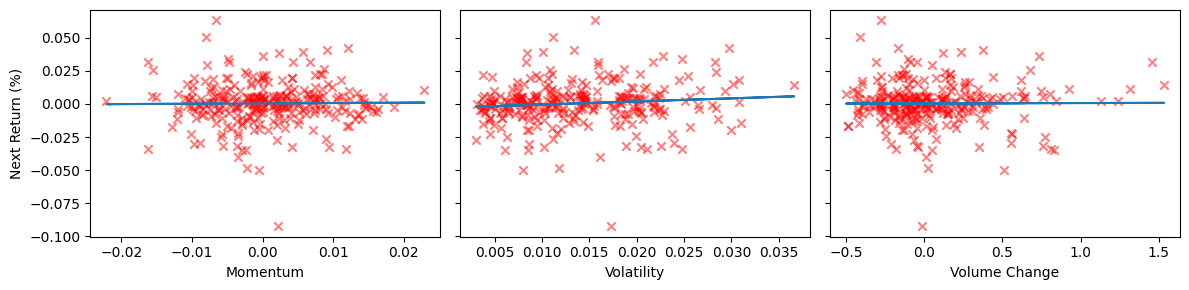

In [111]:
#Features correlation plotting for analysis
fig, ax = plt.subplots(1, len(features), figsize=(12, 3), sharey=True)

for i, feature in enumerate(features):
    x = cleaned_baseline_data[feature]
    y = cleaned_baseline_data["Next Return"]

    # scatter
    ax[i].scatter(x, y, marker="x",c="r",alpha=0.5)

    # regression line
    m, b = np.polyfit(x, y, 1)
    ax[i].plot(x, m*x + b)

    ax[i].set_xlabel(feature)

ax[0].set_ylabel("Next Return (%)")
plt.tight_layout()
plt.show()

#### Gradient Descent without feature engineering

In [112]:
# Input for Gradient descent w/o feature engineering
w_init = np.zeros(len(features))
b_init = 0.0
iteration = 10000
alpha = 0.001
w_final, b_final, J_history, w_history, b_history = run_gradient_descent(cleaned_baseline_feature_train,cleaned_baseline_target_train, w_init, b_init, iteration, alpha)

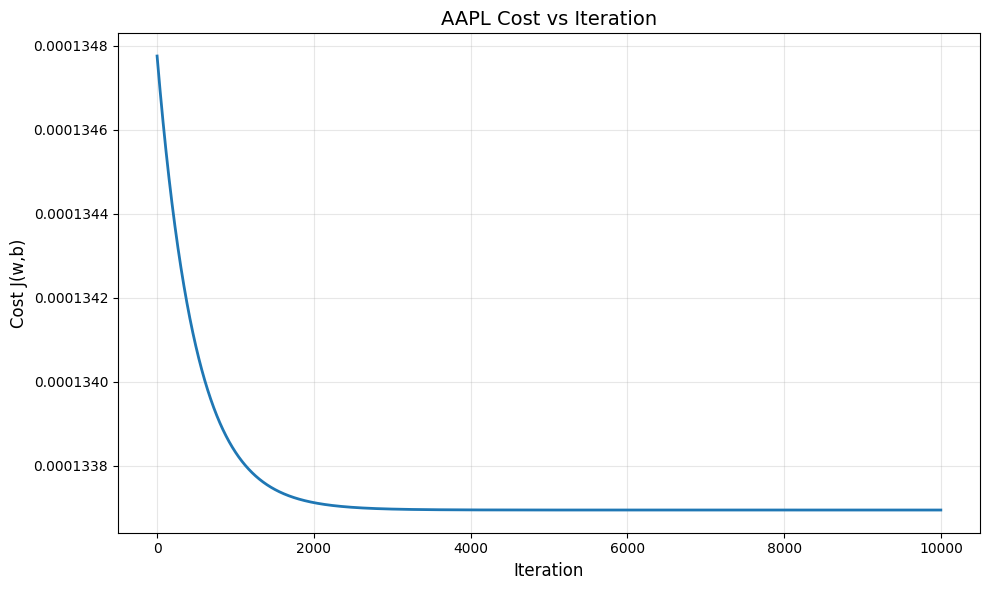

Saved: output/AAPL_cost_vs_iteration.png


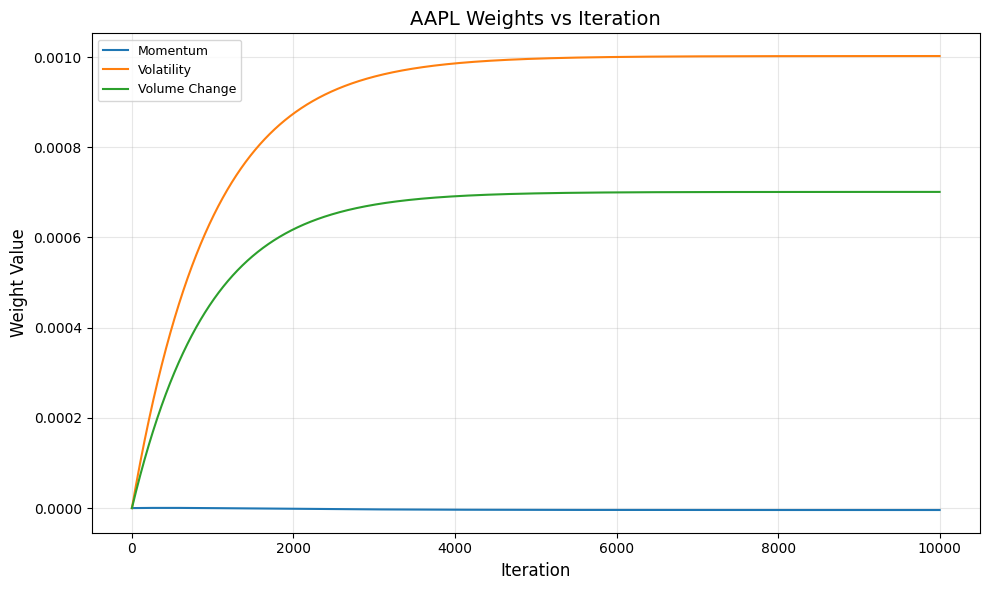

Saved: output/AAPL_weights_vs_iteration.png


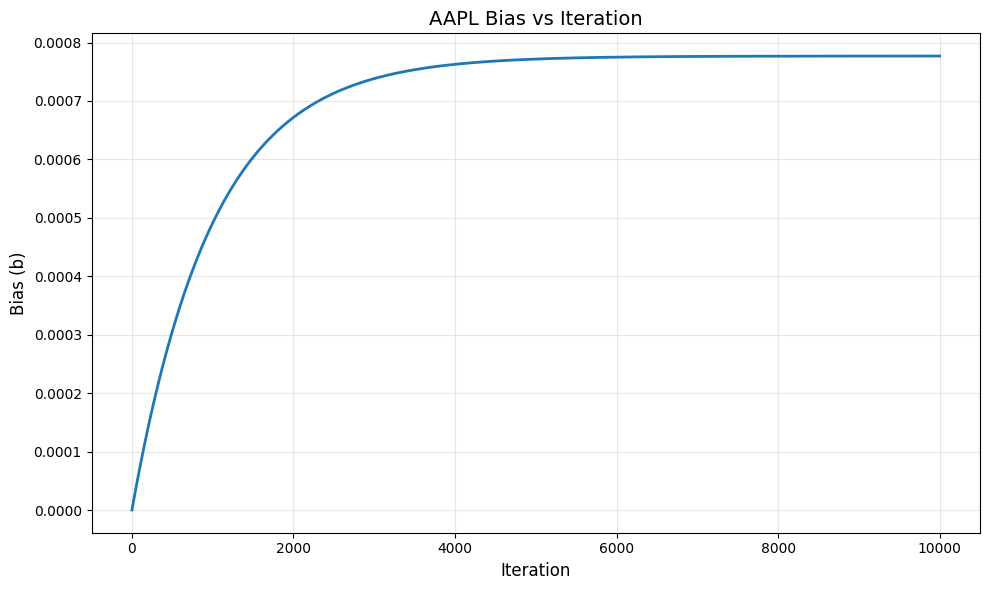

Saved: output/AAPL_bias_vs_iteration.png


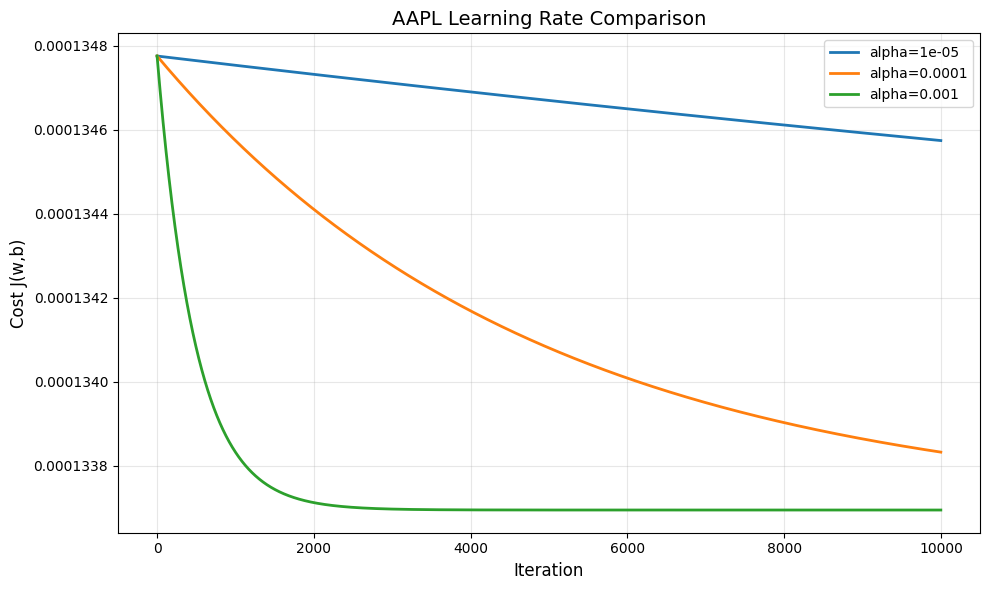

Saved: output/AAPL_learning_rate_comparison.png


In [113]:
# ==========================================
# Cost vs Iteration Plot
# ==========================================
plt.figure(figsize=(10, 6))

plt.plot(J_history, linewidth=2)

plt.xlabel("Iteration", fontsize=12)
plt.ylabel("Cost J(w,b)", fontsize=12)
plt.title(f"{ticker} Cost vs Iteration", fontsize=14)

plt.grid(alpha=0.3)
plt.tight_layout()

# Save plot
cost_plot_path = f"{output_dir}/{ticker}_cost_vs_iteration.png"
plt.savefig(cost_plot_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved: {cost_plot_path}")

# ==========================================
# Weights vs Iteration
# ==========================================
w_history_arr = np.array(w_history)

plt.figure(figsize=(10, 6))

for i in range(w_history_arr.shape[1]):
    plt.plot(
        w_history_arr[:, i],
        label=features[i],
        linewidth=1.5
    )

plt.xlabel("Iteration", fontsize=12)
plt.ylabel("Weight Value", fontsize=12)
plt.title(f"{ticker} Weights vs Iteration", fontsize=14)

plt.legend(loc="best", fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()

# Save plot
weights_plot_path = f"{output_dir}/{ticker}_weights_vs_iteration.png"
plt.savefig(weights_plot_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved: {weights_plot_path}")

# ==========================================
# Bias vs Iteration
# ==========================================
plt.figure(figsize=(10, 6))

plt.plot(b_history, linewidth=2)

plt.xlabel("Iteration", fontsize=12)
plt.ylabel("Bias (b)", fontsize=12)
plt.title(f"{ticker} Bias vs Iteration", fontsize=14)

plt.grid(alpha=0.3)
plt.tight_layout()

# Save plot
bias_plot_path = f"{output_dir}/{ticker}_bias_vs_iteration.png"
plt.savefig(bias_plot_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved: {bias_plot_path}")

# ==========================================
# Cost vs Iteration for Different Learning Rates
# ==========================================
alphas = [0.00001, 0.0001, 0.001]

plt.figure(figsize=(10, 6))

for alpha in alphas:
    w_final, b_final, J_history_alpha, _, _ = run_gradient_descent(
        cleaned_baseline_feature_train,
        cleaned_baseline_target_train,
        w_init,
        b_init,
        iteration,
        alpha
    )
    
    plt.plot(
        J_history_alpha,
        label=f"alpha={alpha}",
        linewidth=2
    )

plt.xlabel("Iteration", fontsize=12)
plt.ylabel("Cost J(w,b)", fontsize=12)
plt.title(f"{ticker} Learning Rate Comparison", fontsize=14)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

# Save plot
alpha_plot_path = f"{output_dir}/{ticker}_learning_rate_comparison.png"
plt.savefig(alpha_plot_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved: {alpha_plot_path}")

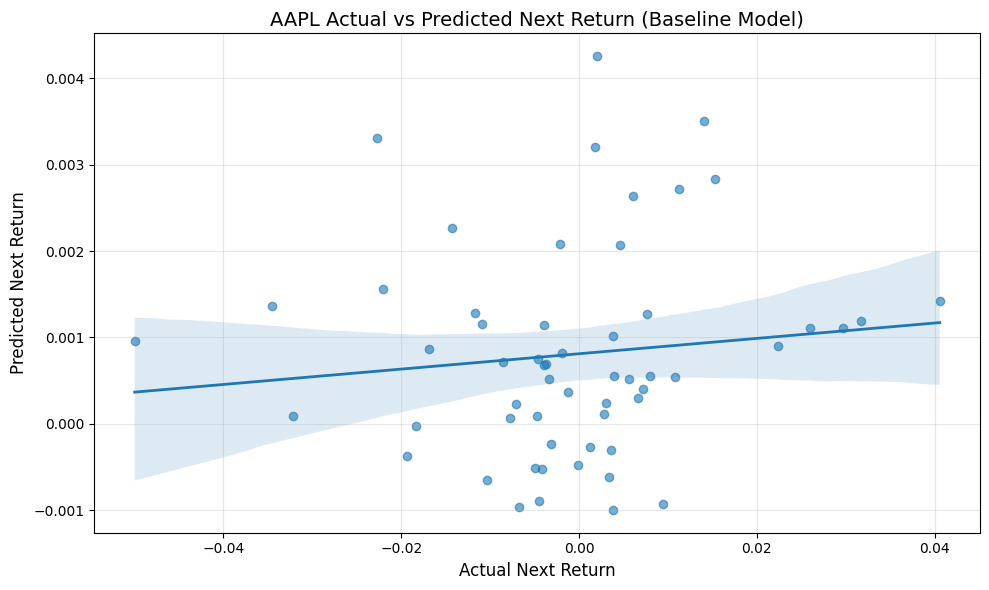

Saved: output/AAPL_baseline_actual_vs_predicted.png
AAPL Next Return Model 
Baseline Model Summary:

R²: -0.0008

Feature Weights:
Momentum Weight: -0.0000
Volatility Weight: 0.0010
Volume Change Weight: 0.0007

Bias: 0.0008


In [114]:
# ==========================================
# Model Evaluation: Actual vs Predicted Plot
# ==========================================
# This section evaluates the baseline linear regression model
# on the test set by comparing:
# - actual next return (ground truth)
# - predicted next return (model output)
# ==========================================

# ------------------------------------------
# Step 1: Generate predictions on the test set
# ------------------------------------------
# Use the trained linear regression parameters (w_final, b_final)
# to predict next return on the baseline test feature matrix.
# Formula:
# y_pred = Xw + b
y_pred_final = cleaned_baseline_feature_test @ w_final + b_final

# ------------------------------------------
# Step 2: Visualization - Actual vs Predicted
# ------------------------------------------
# x-axis: Actual Next Return
# y-axis: Predicted Next Return
# A regplot is used to show:
# - the scatter of prediction vs truth
# - a fitted trend line
plt.figure(figsize=(10, 6))

sns.regplot(
    x=cleaned_baseline_target_test,
    y=y_pred_final,
    scatter_kws={"alpha": 0.6},
    line_kws={"linewidth": 2}
)

plt.xlabel("Actual Next Return", fontsize=12)
plt.ylabel("Predicted Next Return", fontsize=12)
plt.title(f"{ticker} Actual vs Predicted Next Return (Baseline Model)", fontsize=14)

# Add a light grid for readability
plt.grid(alpha=0.3)

# Tight layout for cleaner spacing
plt.tight_layout()

# Save plot
baseline_actual_vs_pred_path = f"{output_dir}/{ticker}_baseline_actual_vs_predicted.png"
plt.savefig(baseline_actual_vs_pred_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved: {baseline_actual_vs_pred_path}")

# ------------------------------------------
# Step 3: Performance Metric - R² Score
# ------------------------------------------
# R² measures how well predicted values explain the variation
# in actual target values.
#
# Interpretation:
# R² = 1   -> perfect fit
# R² = 0   -> same as predicting the mean
# R² < 0   -> worse than naive mean prediction
print(f"{ticker} Next Return Model \nBaseline Model Summary:\n")

r2 = r2_score(cleaned_baseline_target_test, y_pred_final)
print(f"R²: {r2:.4f}")

# ------------------------------------------
# Step 4: Model Interpretation - Feature Weights
# ------------------------------------------
# Display each learned coefficient in the baseline linear model.
# Positive weight  -> feature contributes positively to predicted return
# Negative weight  -> feature contributes negatively to predicted return
print("\nFeature Weights:")
for feature, weight in zip(features, w_final):
    print(f"{feature} Weight: {weight:.4f}")

# Display intercept (bias term)
print(f"\nBias: {b_final:.4f}")

In [115]:
# =========================
# Feature Engineering
# =========================

# Dataframe preparation
df_fe = baseline_data.copy()

# 1. Lag features
df_fe["Return_lag1"] = df_fe["Return"].shift(1)
df_fe["Return_lag5"] = df_fe["Return"].shift(5)

# 2. Rolling statistics
df_fe["Momentum_5"] = df_fe["Return"].rolling(5).mean()
df_fe["Momentum_10"] = df_fe["Return"].rolling(10).mean()

df_fe["Volatility_5"] = df_fe["Return"].rolling(5).std()
df_fe["Volatility_10"] = df_fe["Return"].rolling(10).std()

# 3. Interaction features
df_fe["Mom_x_Vol"] = df_fe["Momentum"] * df_fe["Volatility"]
df_fe["Mom_x_VolChange"] = df_fe["Momentum"] * df_fe["Volume Change"]

# 4. Non-linear features
df_fe["Momentum_sq"] = df_fe["Momentum"] ** 2
df_fe["Volatility_sq"] = df_fe["Volatility"] ** 2

# Drop NaN
df_fe = df_fe.dropna()

new_features = [
    "Momentum", "Volatility", "Volume Change",
    "Return_lag1", "Return_lag5",
    "Momentum_5", "Momentum_10",
    "Volatility_5", "Volatility_10",
    "Mom_x_Vol", "Mom_x_VolChange",
    "Momentum_sq", "Volatility_sq"
]

#Remove outliers from the new features
cleaned_df_fe = remove_outlier(df_fe,new_features)
target = "Next Return"

# Test and Train
cleaned_df_fe_feature_train, cleaned_df_fe_feature_test, cleaned_df_fe_target_train, cleaned_df_fe_target_test = test_train_function (cleaned_df_fe[new_features],cleaned_df_fe["Next Return"])

# ==========================================
# Scaling (fit on train, apply to both)
# ==========================================
scaler_fe = StandardScaler()
cleaned_df_fe_feature_train = scaler_fe.fit_transform(cleaned_df_fe_feature_train)
cleaned_df_fe_feature_test = scaler_fe.transform(cleaned_df_fe_feature_test)

#Property Check
print("X shape:", cleaned_df_fe_feature_train.shape)
print("y shape:", cleaned_df_fe_target_train.shape)

print("NaN in X:", np.isnan(cleaned_df_fe_feature_train).sum())
print("Inf in X:", np.isinf(cleaned_df_fe_feature_train).sum())

print("NaN in y:", np.isnan(cleaned_df_fe_target_train).sum())
print("Inf in y:", np.isinf(cleaned_df_fe_target_train).sum())

print("Max abs X:", np.max(np.abs(cleaned_df_fe_feature_train)))
print("Max abs y:", np.max(np.abs(y)))
cleaned_df_fe = cleaned_df_fe.reset_index(drop=True)
cleaned_df_fe.columns.name = None
cleaned_df_fe.reset_index().head()


X shape: (172, 13)
y shape: (172,)
NaN in X: 0
Inf in X: 0
NaN in y: 0
Inf in y: 0
Max abs X: 4.034191223800223
Max abs y: 0.09245610055374764


,index,Date,Momentum,Volatility,Volume Change,Return,Next Return,Return_lag1,Return_lag5,Momentum_5,Momentum_10,Volatility_5,Volatility_10,Mom_x_Vol,Mom_x_VolChange,Momentum_sq,Volatility_sq
0,0,2025-01-27,0.000103,0.022766,0.734315,0.031780,0.036544,-0.003935,0.007535,0.000103,-0.002780,0.022766,0.021607,0.000002,0.000076,1.062366e-08,0.000518
1,1,2025-01-28,0.013795,0.018964,-0.201930,0.036544,0.004617,0.031780,-0.031916,0.013795,0.001909,0.018964,0.024656,0.000262,-0.002786,1.903020e-04,0.000360
2,2,2025-01-29,0.013649,0.019048,-0.399187,0.004617,-0.007395,0.036544,0.005345,0.013649,0.002849,0.019048,0.024551,0.000260,-0.005449,1.863065e-04,0.000363
3,3,2025-01-30,0.012322,0.020480,0.223633,-0.007395,-0.006692,0.004617,-0.000759,0.012322,0.000142,0.020480,0.023976,0.000252,0.002756,1.518405e-04,0.000419
4,4,2025-02-04,-0.004464,0.020054,-0.383175,0.021008,-0.001418,-0.033856,0.036544,-0.004464,0.004666,0.020054,0.020765,-0.000090,0.001710,1.992390e-05,0.000402


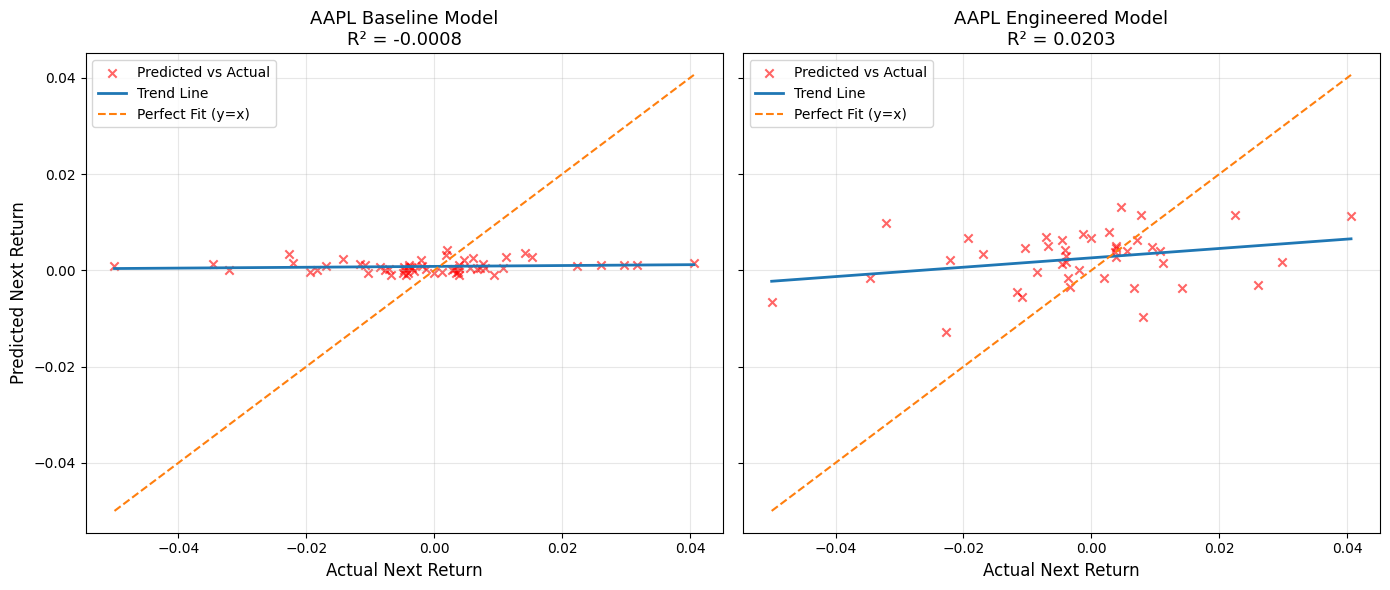

Saved: output/AAPL_baseline_vs_engineered_comparison.png
AAPL Next Return Model
With Feature Engineering Summary:

R²: 0.0203

Feature Weights:
Momentum Weight: 0.0007
Volatility Weight: 0.0003
Volume Change Weight: -0.0007
Return_lag1 Weight: 0.0007
Return_lag5 Weight: 0.0002
Momentum_5 Weight: 0.0007
Momentum_10 Weight: -0.0041
Volatility_5 Weight: 0.0003
Volatility_10 Weight: 0.0018
Mom_x_Vol Weight: 0.0008
Mom_x_VolChange Weight: 0.0029
Momentum_sq Weight: 0.0002
Volatility_sq Weight: -0.0012

Bias: 0.0006


In [116]:
# ==========================================
# Engineered Model: Train on Train Set
# ==========================================
# This section trains the feature-engineered linear regression model
# using only the training set, then evaluates it on the test set.
# ==========================================

# ------------------------------------------
# Step 1: Initialize model parameters
# ------------------------------------------
# w_init_engineering: initial weight vector
# b_init_engineering: initial bias term
# iteration_engineering: number of gradient descent iterations
# alpha_engineering: learning rate
#
# IMPORTANT:
# The number of weights should match the number of engineered features.
w_init_engineering = np.zeros(cleaned_df_fe_feature_train.shape[1])
b_init_engineering = 0.0
iteration_engineering = 10000
alpha_engineering = 0.001

# ------------------------------------------
# Step 2: Train engineered model on train set
# ------------------------------------------
# The model learns weights and bias from engineered training data.
w_final_engineering, b_final_engineering, J_history_eng, w_history_eng, b_history_eng = run_gradient_descent(
    cleaned_df_fe_feature_train,
    cleaned_df_fe_target_train,
    w_init_engineering,
    b_init_engineering,
    iteration_engineering,
    alpha_engineering
)

# ------------------------------------------
# Step 3: Predict on engineered test set
# ------------------------------------------
# Use the learned parameters to predict next return on unseen test data.
# Formula:
# y_pred = Xw + b
y_pred_final_engineering = cleaned_df_fe_feature_test @ w_final_engineering + b_final_engineering

# ------------------------------------------
# Step 4: Evaluate engineered model using R²
# ------------------------------------------
# R² measures how well predicted values explain variation
# in actual next return values on the test set.
r2_engineering = r2_score(cleaned_df_fe_target_test, y_pred_final_engineering)

# ==========================================
# Prepare Plot Data
# ==========================================
# Baseline model (already computed earlier)
x_base = np.array(cleaned_baseline_target_test, dtype=float)   # actual values
y_base = np.array(y_pred_final, dtype=float)                   # predicted values

# Engineered model
x_eng = np.array(cleaned_df_fe_target_test, dtype=float)       # actual values
y_eng = np.array(y_pred_final_engineering, dtype=float)        # predicted values

# ==========================================
# Plot Comparison: Baseline vs Engineered
# ==========================================
# This chart compares:
# - baseline model predictions
# - feature-engineered model predictions
# against actual next return values on the test set.
# ==========================================

fig, ax = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# -------------------------
# Baseline Model
# -------------------------
ax[0].scatter(
    x_base,
    y_base,
    marker="x",
    c="r",
    alpha=0.6,
    label="Predicted vs Actual"
)

# Trend line for baseline model
m_base, b_base = np.polyfit(x_base, y_base, 1)
x_line_base = np.linspace(x_base.min(), x_base.max(), 200)
ax[0].plot(
    x_line_base,
    m_base * x_line_base + b_base,
    linewidth=2,
    label="Trend Line"
)

# Perfect-fit reference line (y = x)
min_val_base = min(x_base.min(), y_base.min())
max_val_base = max(x_base.max(), y_base.max())
ax[0].plot(
    [min_val_base, max_val_base],
    [min_val_base, max_val_base],
    linestyle="--",
    linewidth=1.5,
    label="Perfect Fit (y=x)"
)

ax[0].set_title(f"{ticker} Baseline Model\nR² = {r2:.4f}", fontsize=13)
ax[0].set_xlabel("Actual Next Return", fontsize=12)
ax[0].set_ylabel("Predicted Next Return", fontsize=12)
ax[0].grid(alpha=0.3)
ax[0].legend()

# -------------------------
# Engineered Model
# -------------------------
ax[1].scatter(
    x_eng,
    y_eng,
    marker="x",
    c="r",
    alpha=0.6,
    label="Predicted vs Actual"
)

# Trend line for engineered model
m_eng, b_eng = np.polyfit(x_eng, y_eng, 1)
x_line_eng = np.linspace(x_eng.min(), x_eng.max(), 200)
ax[1].plot(
    x_line_eng,
    m_eng * x_line_eng + b_eng,
    linewidth=2,
    label="Trend Line"
)

# Perfect-fit reference line (y = x)
min_val_eng = min(x_eng.min(), y_eng.min())
max_val_eng = max(x_eng.max(), y_eng.max())
ax[1].plot(
    [min_val_eng, max_val_eng],
    [min_val_eng, max_val_eng],
    linestyle="--",
    linewidth=1.5,
    label="Perfect Fit (y=x)"
)

ax[1].set_title(f"{ticker} Engineered Model\nR² = {r2_engineering:.4f}", fontsize=13)
ax[1].set_xlabel("Actual Next Return", fontsize=12)
ax[1].grid(alpha=0.3)
ax[1].legend()

plt.tight_layout()

# Save plot
comparison_plot_path = f"{output_dir}/{ticker}_baseline_vs_engineered_comparison.png"
plt.savefig(comparison_plot_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved: {comparison_plot_path}")

# ==========================================
# Engineered Model Summary
# ==========================================
print(f"{ticker} Next Return Model\nWith Feature Engineering Summary:\n")
print(f"R²: {r2_engineering:.4f}")

# ==========================================
# Model Interpretation: Engineered Feature Weights
# ==========================================
# Positive weight:
#   higher feature value increases predicted next return
# Negative weight:
#   higher feature value decreases predicted next return
print("\nFeature Weights:")
for feature_name, weight in zip(new_features, w_final_engineering):
    print(f"{feature_name} Weight: {weight:.4f}")

# Bias term (intercept)
print(f"\nBias: {b_final_engineering:.4f}")


### Logistic Regression 

Baseline Model Logistic Regression
Iteration 0, Cost: 0.6931
Iteration 1000, Cost: 0.6878
Iteration 2000, Cost: 0.6877
Iteration 3000, Cost: 0.6877
Iteration 4000, Cost: 0.6877
Iteration 5000, Cost: 0.6877
Iteration 6000, Cost: 0.6877
Iteration 7000, Cost: 0.6877
Iteration 8000, Cost: 0.6877
Iteration 9000, Cost: 0.6877
Accuracy: 0.4918
Confusion Matrix:
[[ 4 28]
 [ 3 26]]
Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.12      0.21        32
           1       0.48      0.90      0.63        29

    accuracy                           0.49        61
   macro avg       0.53      0.51      0.42        61
weighted avg       0.53      0.49      0.41        61



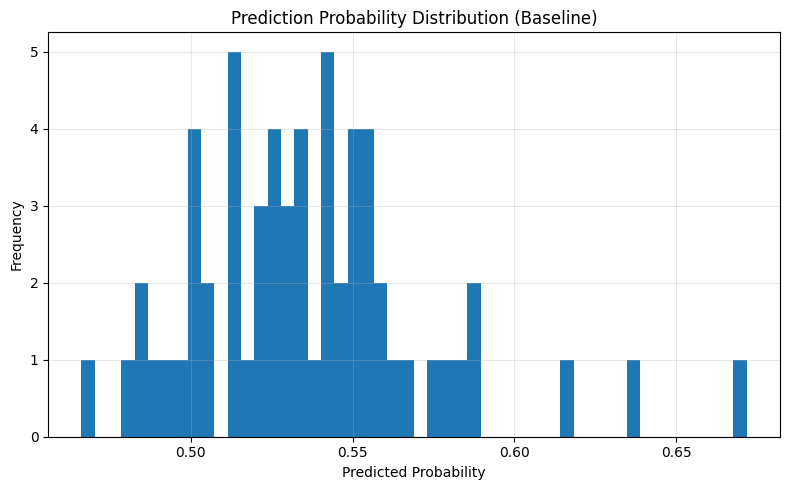

Saved: output/AAPL_baseline_logistic_probability_distribution.png

Logistic Regression with Feature Engineering
Iteration 0, Cost: 0.6930
Iteration 1000, Cost: 0.6595
Iteration 2000, Cost: 0.6568
Iteration 3000, Cost: 0.6558
Iteration 4000, Cost: 0.6552
Iteration 5000, Cost: 0.6548
Iteration 6000, Cost: 0.6544
Iteration 7000, Cost: 0.6541
Iteration 8000, Cost: 0.6539
Iteration 9000, Cost: 0.6537
Accuracy: 0.4884
Confusion Matrix:
[[ 3 20]
 [ 2 18]]
Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.13      0.21        23
           1       0.47      0.90      0.62        20

    accuracy                           0.49        43
   macro avg       0.54      0.52      0.42        43
weighted avg       0.54      0.49      0.40        43



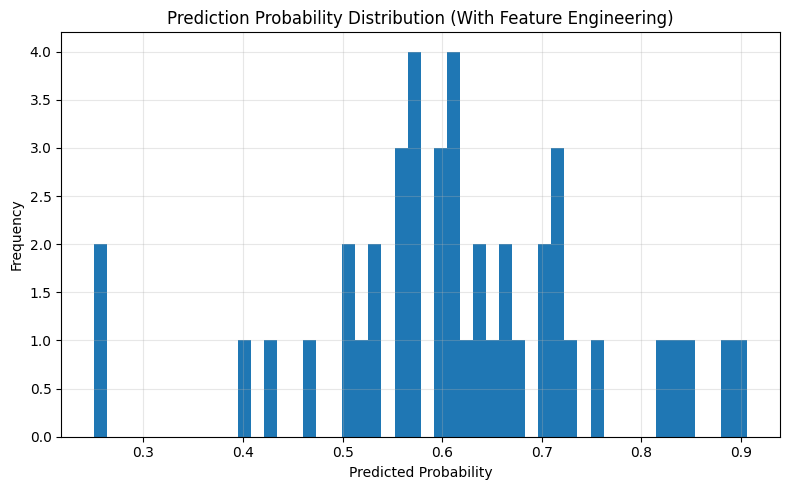

Saved: output/AAPL_engineered_logistic_probability_distribution.png

Baseline Logistic Regression with Regularization
Iteration 0, Cost: 0.6931
Iteration 1000, Cost: 0.6878
Iteration 2000, Cost: 0.6877
Iteration 3000, Cost: 0.6877
Iteration 4000, Cost: 0.6877
Iteration 5000, Cost: 0.6877
Iteration 6000, Cost: 0.6877
Iteration 7000, Cost: 0.6877
Iteration 8000, Cost: 0.6877
Iteration 9000, Cost: 0.6877
Accuracy: 0.4918
Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.12      0.21        32
           1       0.48      0.90      0.63        29

    accuracy                           0.49        61
   macro avg       0.53      0.51      0.42        61
weighted avg       0.53      0.49      0.41        61



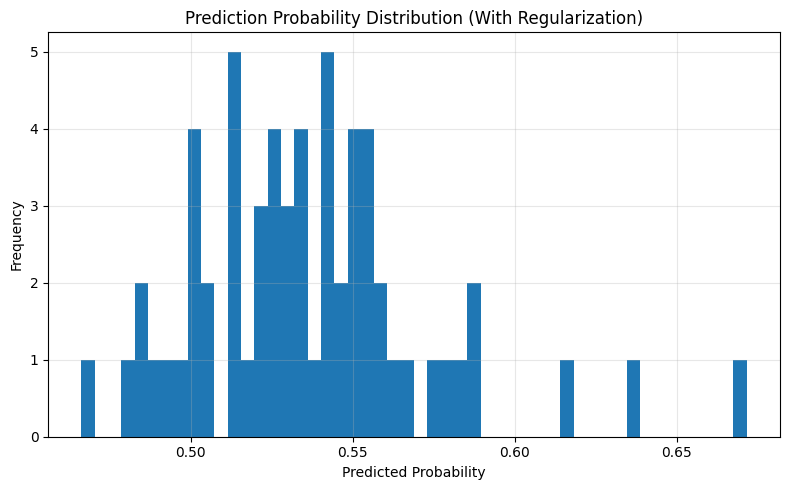

Saved: output/AAPL_baseline_regularized_logistic_probability_distribution.png
Logistic Regression with vs. without regularization:
No reg accuracy: 0.4918
Reg accuracy: 0.4918

No reg mean prob: 0.5365
Reg mean prob: 0.5365

No reg weight norm: 0.1693
Reg weight norm: 0.1690


In [117]:
# ==========================================
# Baseline Logistic Regression
# ==========================================
print("Baseline Model Logistic Regression")

# Create binary classification target:
# 1 = next return is positive
# 0 = next return is zero or negative
log_reg = baseline_data.copy()
log_reg["Target"] = (log_reg["Next Return"] > 0).astype(int)

# ------------------------------------------
# Step 1: Time-based train/test split
# ------------------------------------------
cleaned_baseline_feature_train_log, cleaned_baseline_feature_test_log, \
cleaned_baseline_target_train_log, cleaned_baseline_target_test_log = test_train_function(
    log_reg[features],
    log_reg["Target"]
)

# ------------------------------------------
# Step 2: Scale features
# IMPORTANT:
# Fit scaler on training features only,
# then transform both train and test features.
# ------------------------------------------
scaler_log = StandardScaler()
cleaned_baseline_feature_train_log = scaler_log.fit_transform(cleaned_baseline_feature_train_log)
cleaned_baseline_feature_test_log = scaler_log.transform(cleaned_baseline_feature_test_log)

# ------------------------------------------
# Step 3: Initialize logistic regression parameters
# ------------------------------------------
b_log_init = 0.0
w_log_init = np.zeros(len(features))

# ------------------------------------------
# Step 4: Train logistic regression model
# ------------------------------------------
w_log_final, b_log_final = logistic_gradient_descent(
    cleaned_baseline_feature_train_log,
    cleaned_baseline_target_train_log,
    w_log_init,
    b_log_init,
    alpha=0.01,
    iterations=10000
)

# ------------------------------------------
# Step 5: Predict probabilities on test set
# ------------------------------------------
prob = sigmoid(cleaned_baseline_feature_test_log @ w_log_final + b_log_final)

# Convert probabilities into class labels using threshold = 0.5
y_pred_log = (prob >= 0.5).astype(int)

# ------------------------------------------
# Step 6: Evaluate baseline logistic model
# ------------------------------------------
accuracy_log = np.mean(y_pred_log == cleaned_baseline_target_test_log)
print(f"Accuracy: {accuracy_log:.4f}")

cm = confusion_matrix(cleaned_baseline_target_test_log, y_pred_log)
print("Confusion Matrix:")
print(cm)

print("Classification Report:")
print(classification_report(cleaned_baseline_target_test_log, y_pred_log))

# ------------------------------------------
# Step 7: Plot probability distribution
# ------------------------------------------
plt.figure(figsize=(8, 5))
plt.hist(prob, bins=50)
plt.title("Prediction Probability Distribution (Baseline)")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.tight_layout()

baseline_prob_plot_path = f"{output_dir}/{ticker}_baseline_logistic_probability_distribution.png"
plt.savefig(baseline_prob_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {baseline_prob_plot_path}")


# ==========================================
# Logistic Regression with Feature Engineering
# ==========================================
print("\nLogistic Regression with Feature Engineering")

# Create binary target for engineered dataset
cleaned_df_fe["Target"] = (cleaned_df_fe["Next Return"] > 0).astype(int)

# ------------------------------------------
# Step 1: Time-based train/test split
# ------------------------------------------
cleaned_df_fe_feature_train_fe_log, cleaned_df_fe_feature_test_fe_log, \
cleaned_df_fe_target_train_fe_log, cleaned_df_fe_target_test_fe_log = test_train_function(
    cleaned_df_fe[new_features],
    cleaned_df_fe["Target"]
)

# ------------------------------------------
# Step 2: Scale engineered features
# ------------------------------------------
scaler_log_fe = StandardScaler()
cleaned_df_fe_feature_train_fe_log = scaler_log_fe.fit_transform(cleaned_df_fe_feature_train_fe_log)
cleaned_df_fe_feature_test_fe_log = scaler_log_fe.transform(cleaned_df_fe_feature_test_fe_log)

# ------------------------------------------
# Step 3: Initialize parameters
# ------------------------------------------
b_log_fe_init = 0.0
w_log_fe_init = np.zeros(len(new_features))

# ------------------------------------------
# Step 4: Train engineered logistic model
# ------------------------------------------
w_log_fe_final, b_log_fe_final = logistic_gradient_descent(
    cleaned_df_fe_feature_train_fe_log,
    cleaned_df_fe_target_train_fe_log,
    w_log_fe_init,
    b_log_fe_init,
    alpha=0.01,
    iterations=10000
)

# ------------------------------------------
# Step 5: Predict on engineered test set
# ------------------------------------------
prob_fe = sigmoid(cleaned_df_fe_feature_test_fe_log @ w_log_fe_final + b_log_fe_final)
y_pred_log_fe = (prob_fe >= 0.5).astype(int)

# ------------------------------------------
# Step 6: Evaluate engineered logistic model
# ------------------------------------------
accuracy_fe_log = np.mean(y_pred_log_fe == cleaned_df_fe_target_test_fe_log)
print(f"Accuracy: {accuracy_fe_log:.4f}")

print("Confusion Matrix:")
print(confusion_matrix(cleaned_df_fe_target_test_fe_log, y_pred_log_fe))

print("Classification Report:")
print(classification_report(cleaned_df_fe_target_test_fe_log, y_pred_log_fe))

# ------------------------------------------
# Step 7: Plot probability distribution
# ------------------------------------------
plt.figure(figsize=(8, 5))
plt.hist(prob_fe, bins=50)
plt.title("Prediction Probability Distribution (With Feature Engineering)")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.tight_layout()

fe_prob_plot_path = f"{output_dir}/{ticker}_engineered_logistic_probability_distribution.png"
plt.savefig(fe_prob_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {fe_prob_plot_path}")


# ==========================================
# Baseline Logistic Regression with Regularization
# ==========================================
print("\nBaseline Logistic Regression with Regularization")

# Initialize parameters for regularized model
w_init_reg = np.zeros(cleaned_baseline_feature_train_log.shape[1])
b_init_reg = 0.0

alpha_reg = 0.01
iterations = 10000
lambda_ = 0.1

# ------------------------------------------
# Train regularized logistic regression
# IMPORTANT:
# use alpha_reg, not alpha
# ------------------------------------------
w_reg, b_reg, J_hist_reg, w_hist_reg, b_hist_reg = gradient_descent_logistic_reg(
    cleaned_baseline_feature_train_log,
    cleaned_baseline_target_train_log,
    w_init_reg,
    b_init_reg,
    alpha_reg,
    iterations,
    lambda_
)

# Predict probabilities on baseline test set
prob_reg = sigmoid(cleaned_baseline_feature_test_log @ w_reg + b_reg)
y_pred_reg = (prob_reg >= 0.5).astype(int)

# Evaluate regularized model
accuracy_reg_log = np.mean(y_pred_reg == cleaned_baseline_target_test_log)
print(f"Accuracy: {accuracy_reg_log:.4f}")

print("Classification Report:")
print(classification_report(cleaned_baseline_target_test_log, y_pred_reg))
plt.figure(figsize=(8, 5))
plt.hist(prob_reg, bins=50)
plt.title("Prediction Probability Distribution (With Regularization)")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.tight_layout()

reg_prob_plot_path = f"{output_dir}/{ticker}_baseline_regularized_logistic_probability_distribution.png"
plt.savefig(reg_prob_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {reg_prob_plot_path}")


# ==========================================
# Comparison: With vs Without Regularization
# ==========================================
print("Logistic Regression with vs. without regularization:")

print(f"No reg accuracy: {accuracy_log:.4f}")
print(f"Reg accuracy: {accuracy_reg_log:.4f}")

print(f"\nNo reg mean prob: {np.mean(prob):.4f}")
print(f"Reg mean prob: {np.mean(prob_reg):.4f}")

print(f"\nNo reg weight norm: {np.linalg.norm(w_log_final):.4f}")
print(f"Reg weight norm: {np.linalg.norm(w_reg):.4f}")

### Logistic Regression w/ Feature Engineering

### Logistic regression with regularization

In [118]:
# ==========================================
# Save cleaned datasets before train/test split
# ==========================================
# These files are useful for:
# - reproducibility
# - debugging
# - documenting the data used for modeling
# ==========================================

# ------------------------------------------
# Save full cleaned datasets
# ------------------------------------------
baseline_path = f"{output_dir}/{ticker}_baseline_cleaned_{timestamp}.csv"
cleaned_baseline_data.to_csv(baseline_path, index=True)

engineered_path = f"{output_dir}/{ticker}_engineered_cleaned_{timestamp}.csv"
cleaned_df_fe.to_csv(engineered_path, index=True)

log_path = f"{output_dir}/{ticker}_log_cleaned_{timestamp}.csv"
log_reg.to_csv(log_path, index=True)

# ------------------------------------------
# Save train/test splits (Baseline)
# ------------------------------------------
X_train_base_path = f"{output_dir}/{ticker}_baseline_X_train_{timestamp}.csv"
X_test_base_path  = f"{output_dir}/{ticker}_baseline_X_test_{timestamp}.csv"
y_train_base_path = f"{output_dir}/{ticker}_baseline_y_train_{timestamp}.csv"
y_test_base_path  = f"{output_dir}/{ticker}_baseline_y_test_{timestamp}.csv"

pd.DataFrame(cleaned_baseline_feature_train_log).to_csv(X_train_base_path, index=False)
pd.DataFrame(cleaned_baseline_feature_test_log).to_csv(X_test_base_path, index=False)
pd.DataFrame(cleaned_baseline_target_train_log).to_csv(y_train_base_path, index=False)
pd.DataFrame(cleaned_baseline_target_test_log).to_csv(y_test_base_path, index=False)

# ------------------------------------------
# Save train/test splits (Engineered)
# ------------------------------------------
X_train_fe_path = f"{output_dir}/{ticker}_engineered_X_train_{timestamp}.csv"
X_test_fe_path  = f"{output_dir}/{ticker}_engineered_X_test_{timestamp}.csv"
y_train_fe_path = f"{output_dir}/{ticker}_engineered_y_train_{timestamp}.csv"
y_test_fe_path  = f"{output_dir}/{ticker}_engineered_y_test_{timestamp}.csv"

pd.DataFrame(cleaned_df_fe_feature_train_fe_log).to_csv(X_train_fe_path, index=False)
pd.DataFrame(cleaned_df_fe_feature_test_fe_log).to_csv(X_test_fe_path, index=False)
pd.DataFrame(cleaned_df_fe_target_train_fe_log).to_csv(y_train_fe_path, index=False)
pd.DataFrame(cleaned_df_fe_target_test_fe_log).to_csv(y_test_fe_path, index=False)

# ------------------------------------------
# Confirmation
# ------------------------------------------
print("✅ All datasets saved successfully:")
print(f"- Baseline cleaned: {baseline_path}")
print(f"- Engineered cleaned: {engineered_path}")
print(f"- Logistic cleaned: {log_path}")

print("\n📊 Baseline Train/Test:")
print(f"- X_train: {X_train_base_path}")
print(f"- X_test:  {X_test_base_path}")
print(f"- y_train: {y_train_base_path}")
print(f"- y_test:  {y_test_base_path}")

print("\n📊 Engineered Train/Test:")
print(f"- X_train: {X_train_fe_path}")
print(f"- X_test:  {X_test_fe_path}")
print(f"- y_train: {y_train_fe_path}")
print(f"- y_test:  {y_test_fe_path}")

print("Cleaned datasets saved successfully.")

✅ All datasets saved successfully:
- Baseline cleaned: output/AAPL_baseline_cleaned_20260327_021801.csv
- Engineered cleaned: output/AAPL_engineered_cleaned_20260327_021801.csv
- Logistic cleaned: output/AAPL_log_cleaned_20260327_021801.csv

📊 Baseline Train/Test:
- X_train: output/AAPL_baseline_X_train_20260327_021801.csv
- X_test:  output/AAPL_baseline_X_test_20260327_021801.csv
- y_train: output/AAPL_baseline_y_train_20260327_021801.csv
- y_test:  output/AAPL_baseline_y_test_20260327_021801.csv

📊 Engineered Train/Test:
- X_train: output/AAPL_engineered_X_train_20260327_021801.csv
- X_test:  output/AAPL_engineered_X_test_20260327_021801.csv
- y_train: output/AAPL_engineered_y_train_20260327_021801.csv
- y_test:  output/AAPL_engineered_y_test_20260327_021801.csv
Cleaned datasets saved successfully.
